<a href="https://colab.research.google.com/github/femiraj26/Website-Behaviour-Analytics/blob/main/Website_Behaviour_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Goal:**

Analyze how users behave on a website and answer:

* Which pages are visited the most?
* Which pages have the highest engagement?
* Which traffic source performs best?
* Which device users prefer?
* What is the conversion rate?
* What business recommendations can be given?

Upload Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving AIML TASK 3 DATASET - website_behavior_dataset.csv to AIML TASK 3 DATASET - website_behavior_dataset.csv


Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Read the Dataset

In [4]:
df = pd.read_csv("AIML TASK 3 DATASET - website_behavior_dataset.csv")

Reads the first 5 rows of the dataset

In [5]:
df.head()

,user_id,session_id,page,time_spent_seconds,clicks,scroll_percentage,device_type,traffic_source,timestamp,converted
0,U055,S001,Contact,207,10,19,Mobile,LinkedIn,2026-06-11 16:21:00,No
1,U076,S002,About,52,0,26,Tablet,Referral,2026-06-03 18:26:00,Yes
2,U010,S003,Home,119,9,71,Tablet,Referral,2026-06-12 02:53:00,No
3,U075,S004,Demo,106,8,43,Tablet,Referral,2026-06-08 22:52:00,Yes
4,U018,S005,About,36,13,16,Desktop,Google,2026-06-07 11:15:00,No


Understand the Columns and dataset informations

In [6]:
df.columns

Index(['user_id', 'session_id', 'page', 'time_spent_seconds', 'clicks',
       'scroll_percentage', 'device_type', 'traffic_source', 'timestamp',
       'converted'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   user_id             200 non-null    object
 1   session_id          200 non-null    object
 2   page                200 non-null    object
 3   time_spent_seconds  200 non-null    int64 
 4   clicks              200 non-null    int64 
 5   scroll_percentage   200 non-null    int64 
 6   device_type         200 non-null    object
 7   traffic_source      200 non-null    object
 8   timestamp           200 non-null    object
 9   converted           200 non-null    object
dtypes: int64(3), object(7)
memory usage: 15.8+ KB


In [8]:
df.shape

(200, 10)

Check for missing values:

In [9]:
df.isnull().sum()

,0
user_id,0
session_id,0
page,0
time_spent_seconds,0
clicks,0
scroll_percentage,0
device_type,0
traffic_source,0
timestamp,0
converted,0


## Which page gets maximum visitors?

In [10]:
page_visits = df['page'].value_counts()

print(page_visits)

page
Blog        30
Pricing     28
Checkout    28
Demo        27
Home        26
Contact     21
About       20
Products    20
Name: count, dtype: int64


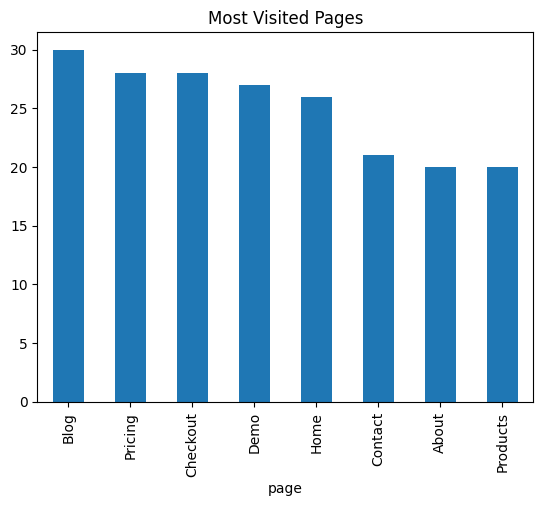

In [11]:
page_visits.plot(kind='bar')

plt.title("Most Visited Pages")

plt.show()

Insight:Blog attracts maximum traffic.

## Which pages have the highest engagement?

In [12]:
engagement = df.groupby(
'page'
)['time_spent_seconds'].mean()

print(engagement)

page
About       150.850000
Blog        133.100000
Checkout    143.178571
Contact     204.285714
Demo        142.185185
Home        146.230769
Pricing     146.535714
Products    128.100000
Name: time_spent_seconds, dtype: float64


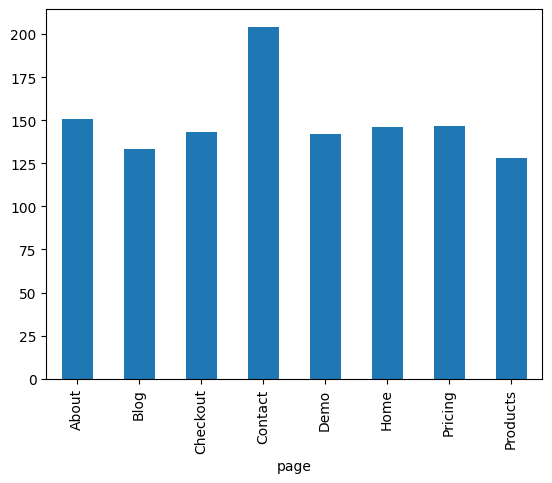

In [13]:
engagement.plot(kind='bar')

plt.show()

**Insight:**

Users spend more time on:

* Contact
* About
* Pricing

These pages are important for conversions.

##Which traffic source performs best?

In [14]:
traffic = df['traffic_source'].value_counts()

print(traffic)

traffic_source
Google       37
Direct       36
Instagram    33
LinkedIn     32
YouTube      32
Referral     30
Name: count, dtype: int64


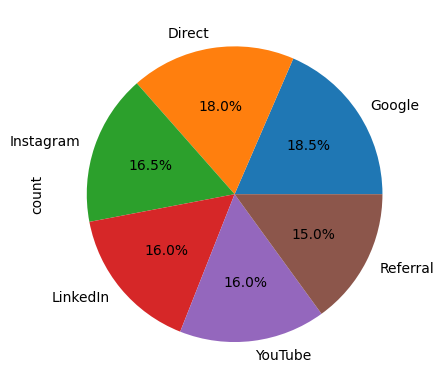

In [15]:
traffic.plot(
kind='pie',
autopct='%1.1f%%'
)

plt.show()

**Insight**

Google brings maximum visitors.

##Which device users prefer?

In [16]:
device=df['device_type'].value_counts()

print(device)

device_type
Tablet     71
Desktop    69
Mobile     60
Name: count, dtype: int64


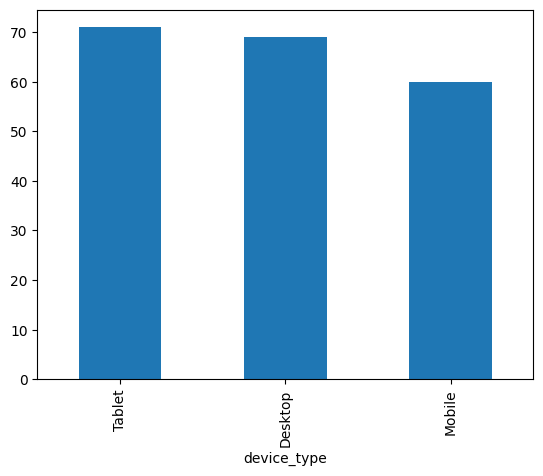

In [17]:
device.plot(kind='bar')

plt.show()

**Website should support:**

* Mobile
* Desktop
* Tablet

##What is the conversion rate?

In [18]:
df['converted_num'] = df['converted'].map({'Yes':1,'No':0})

In [19]:
conversion_rate = df['converted_num'].mean()*100

print(conversion_rate)

25.0


**Insight**
Out of 100 visitors, 25 become customers

##What business recommendations can be given?

In [20]:
source_conversion =df.groupby('traffic_source')['converted_num'].mean()*100

print(source_conversion)

traffic_source
Direct       25.000000
Google       27.027027
Instagram    18.181818
LinkedIn     21.875000
Referral     30.000000
YouTube      28.125000
Name: converted_num, dtype: float64


**Insight**
Referral converts the best.

Company should:

* Promote referrals
* Offer referral rewards

##Save and download processed csv

In [21]:
df.to_csv('processed_website_data.csv',index=False)

In [22]:
from google.colab import files

files.download('processed_website_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##User Segmentation

In [25]:
user_segments = df.groupby('traffic_source').agg({
    'session_id':'nunique',
    'converted_num':'mean'
})

print(user_segments)

                session_id  converted_num
traffic_source                           
Direct                  36       0.250000
Google                  37       0.270270
Instagram               33       0.181818
LinkedIn                32       0.218750
Referral                30       0.300000
YouTube                 32       0.281250


##Customer Clustering

In [27]:
from sklearn.cluster import KMeans

features = df[['time_spent_seconds','scroll_percentage']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(features)

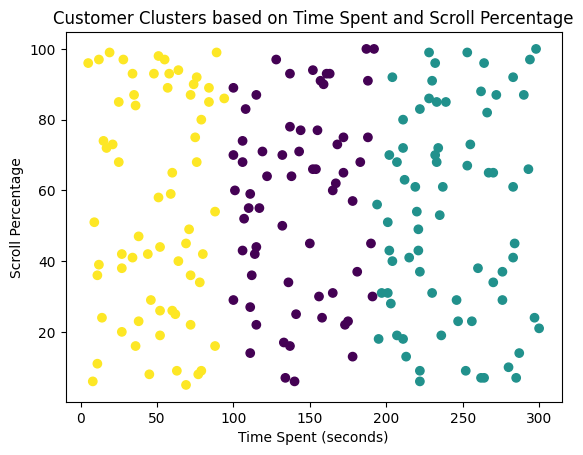

In [29]:
import matplotlib.pyplot as plt

plt.scatter(df['time_spent_seconds'],
            df['scroll_percentage'],
            c=df['cluster'])
plt.xlabel('Time Spent (seconds)')
plt.ylabel('Scroll Percentage')
plt.title('Customer Clusters based on Time Spent and Scroll Percentage')
plt.show()

##Conversion Prediction

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df[['time_spent_seconds','scroll_percentage']]
y = df['converted_num']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = RandomForestClassifier()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.7
